In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os
import random
import numpy as np
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup, AutoTokenizer, AutoConfig
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Split Data

In [3]:
# 1. Persiapan Data (Simulasi)
data = pd.read_csv("/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/dataset/Komentar_Youtube_bersih_berlabel_3.csv")
df = pd.DataFrame(data)

# Pisahkan fitur (X) dan target/label (y)
X = df['Teks']
y = df['Label']

# 2. Langkah Pertama: Pisahkan Data Uji (Test)
# Kita ambil 15% untuk Test, sisanya 85% akan menjadi data latih sementara (Train + Val)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y  # Menjaga proporsi kelas (Positif/Negatif) tetap seimbang
)

# 3. Langkah Kedua: Pisahkan sisa data (X_temp) menjadi Train dan Validation
# Kita ingin Validation menjadi 15% dari TOTAL data awal.
# Karena X_temp adalah 85% dari total, maka persentase pembagiannya adalah: 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=(0.15 / 0.85),
    random_state=42,
    stratify=y_temp
)

# 4. (Opsional) Gabungkan kembali menjadi DataFrame agar rapi
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
val_df = pd.DataFrame({'text': X_val, 'label': y_val})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

# 5. Tampilkan Hasil Pembagian
print("=== HASIL PEMBAGIAN DATA ===")
print(f"Total Data Awal: {len(df)}")
print(f"Data Latih (Train)  : {len(train_df)} data ({(len(train_df)/len(df))*100:.0f}%)")
print(f"Data Validasi (Val) : {len(val_df)} data ({(len(val_df)/len(df))*100:.0f}%)")
print(f"Data Uji (Test)     : {len(test_df)} data ({(len(test_df)/len(df))*100:.0f}%)")

=== HASIL PEMBAGIAN DATA ===
Total Data Awal: 10990
Data Latih (Train)  : 7692 data (70%)
Data Validasi (Val) : 1649 data (15%)
Data Uji (Test)     : 1649 data (15%)


In [4]:
print("Jumlah kelas dalam data training:")
print(train_df['label'].value_counts())

print("\nJumlah kelas dalam data validasi:")
print(val_df['label'].value_counts())

print("\nJumlah kelas dalam data test:")
print(test_df['label'].value_counts())

Jumlah kelas dalam data training:
label
Neutral     3367
Negative    3272
Positive    1053
Name: count, dtype: int64

Jumlah kelas dalam data validasi:
label
Neutral     722
Negative    701
Positive    226
Name: count, dtype: int64

Jumlah kelas dalam data test:
label
Neutral     722
Negative    701
Positive    226
Name: count, dtype: int64


# Tokenizing

In [5]:
# 1. Definisikan path model dari Hugging Face yang kamu gunakan
# (Sesuaikan path ini jika kamu menggunakan versi spesifik lainnya)
model_paths = {
    "IndoBERT": "indobenchmark/indobert-base-p1",
    "IndoRoBERTa": "cahya/roberta-base-indonesian-522M",
    "indoBERTweet": "indolem/indobertweet-base-uncased"
}

# 2. Inisialisasi dictionary untuk menyimpan ketiga tokenizer
tokenizers = {}
for model_name, path in model_paths.items():
    print(f"Mengunduh tokenizer untuk {model_name}...")
    tokenizers[model_name] = AutoTokenizer.from_pretrained(path)

# 3. Fungsi Tokenisasi
def tokenize_data(texts, tokenizer, max_length=128):
    return tokenizer(
        texts.tolist(),
        padding='max_length', # Menyamakan panjang kalimat (menambah angka 0 jika kalimat pendek)
        truncation=True,      # Memotong kalimat jika melebihi max_length
        max_length=max_length,
        return_tensors='pt'   # 'pt' untuk PyTorch, ubah jadi 'tf' jika pakai TensorFlow
    )

Mengunduh tokenizer untuk IndoBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Mengunduh tokenizer untuk indoBERTweet...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [6]:
# ==========================================
# Tokenizing
# ==========================================

# 4. Lakukan tokenisasi untuk Masing-masing Model dan Masing-masing Split
print("\nMelakukan Tokenisasi untuk Train, Val, dan Test...")
tokenized_inputs = {}

for model_name, tokenizer in tokenizers.items():
    print(f"-> Memproses {model_name}...")
    tokenized_inputs[model_name] = {
        # Ganti 'text' dengan nama kolom Anda
        'train': tokenize_data(train_df['text'], tokenizer),
        'val': tokenize_data(val_df['text'], tokenizer),
        'test': tokenize_data(test_df['text'], tokenizer)
    }

print("Selesai! Data siap digunakan untuk PyTorch/TensorFlow.")


Melakukan Tokenisasi untuk Train, Val, dan Test...
-> Memproses IndoBERT...
-> Memproses IndoRoBERTa...
-> Memproses indoBERTweet...
Selesai! Data siap digunakan untuk PyTorch/TensorFlow.


In [7]:
print("Kolom yang tersedia di dalam data tokenized (contoh IndoBERT, train split):")
# Ambil salah satu model dan split untuk contoh
example_tokenized_data = tokenized_inputs["IndoBERT"]['train']

# Cetak kunci-kunci (kolom) yang ada
for key in example_tokenized_data.keys():
    print(f"- {key}")

# Jika ingin melihat bentuk datanya, contoh:
print("\nBentuk data 'input_ids' untuk IndoBERT (train):")
print(example_tokenized_data['input_ids'].shape)

Kolom yang tersedia di dalam data tokenized (contoh IndoBERT, train split):
- input_ids
- token_type_ids
- attention_mask

Bentuk data 'input_ids' untuk IndoBERT (train):
torch.Size([7692, 128])


In [8]:
input_ids_train_indobert = tokenized_inputs["IndoBERT"]['train']['input_ids']
print (input_ids_train_indobert)

input_ids_train_indoroberta = tokenized_inputs["IndoRoBERTa"]['train']['input_ids']
print (input_ids_train_indoroberta)

input_ids_train_indobertweet = tokenized_inputs["indoBERTweet"]['train']['input_ids']
print (input_ids_train_indobertweet)

tensor([[    2,  8563,    98,  ...,     0,     0,     0],
        [    2,  2414,  8563,  ...,     0,     0,     0],
        [    2, 27764,     3,  ...,     0,     0,     0],
        ...,
        [    2, 29397, 10532,  ...,     0,     0,     0],
        [    2,  2913,   711,  ...,     0,     0,     0],
        [    2,   531,   427,  ...,     0,     0,     0]])
tensor([[    0,  1250,   323,  ...,     1,     1,     1],
        [    0,  6358,   225,  ...,     1,     1,     1],
        [    0,  6077,   307,  ...,     1,     1,     1],
        ...,
        [    0,   283, 23173,  ...,     1,     1,     1],
        [    0,  9007,  1168,  ...,     1,     1,     1],
        [    0,  9364,   759,  ...,     1,     1,     1]])
tensor([[    3,  5787,  1542,  ...,     0,     0,     0],
        [    3,  2793,  5787,  ...,     0,     0,     0],
        [    3, 24650,     4,  ...,     0,     0,     0],
        ...,
        [    3, 25479,  5402,  ...,     0,     0,     0],
        [    3,  5168,  2323,  

# Training

In [9]:
# ==========================================
# 1. Konfigurasi Seed & Device
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# ==========================================
# 2. Hyperparameters
# ==========================================
EPOCHS = 5
BATCH_SIZE = 16
LEARNING_RATE = 1e-5
NUM_LABELS = len(train_df['label'].unique()) # Mendeteksi jumlah kelas secara otomatis
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Jumlah Kelas: {NUM_LABELS}")

# ==========================================
# 3. PyTorch Dataset Class
# ==========================================
class SentimentDataset(Dataset):
    def __init__(self, tokenized_data, labels):
        self.input_ids = tokenized_data['input_ids']
        self.attention_mask = tokenized_data['attention_mask']
        # Check if token_type_ids exist. If not, create a tensor of zeros.
        if 'token_type_ids' in tokenized_data:
            self.token_type_ids = tokenized_data['token_type_ids']
        else:
            # Create a tensor of zeros for token_type_ids if not provided by tokenizer
            # Shape should match input_ids
            self.token_type_ids = torch.zeros_like(self.input_ids, dtype=torch.long)
        self.labels = torch.tensor(labels.values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'token_type_ids': self.token_type_ids[idx], # Always include token_type_ids
            'labels': self.labels[idx]
        }
        return item

# ==========================================
# 4. Fungsi Bantuan untuk Evaluasi Akhir
# ==========================================
def plot_confusion_matrix_with_labels(y_true, y_pred, labels, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def evaluate_metrics(y_true, y_pred):
    # Menggunakan average='macro' agar aman untuk binary maupun multi-class
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"Accuracy  : {acc:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")

# ==========================================
# 5. Label Mapping
# ==========================================
# Get unique labels and create a mapping
unique_labels = sorted(train_df['label'].unique().tolist())
label_to_id = {label: i for i, label in enumerate(unique_labels)}

# Apply mapping to labels
train_labels_encoded = train_df['label'].map(label_to_id)
val_labels_encoded = val_df['label'].map(label_to_id)
test_labels_encoded = test_df['label'].map(label_to_id)

Menggunakan device: cuda
Epochs: 5
Batch Size: 16
Jumlah Kelas: 3


In [10]:
# ==========================================
# 6. Menghitung Class Weights (Penanganan Imbalance)
# ==========================================
# Pastikan train_labels_encoded adalah array atau list
labels_array = train_labels_encoded.values

# Menghitung bobot kelas (balanced akan otomatis memberi bobot besar ke kelas minoritas)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)

# Ubah ke tensor PyTorch dan pindahkan ke device (GPU/CPU)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Bobot Kelas (Class Weights):")
for i, weight in enumerate(class_weights):
    print(f"  {unique_labels[i]}: {weight:.4f}")

# Inisialisasi Loss Function menggunakan bobot yang sudah dibuat
# Gunakan criterion ini di dalam training loop nanti
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

Bobot Kelas (Class Weights):
  Negative: 0.7836
  Neutral: 0.7615
  Positive: 2.4349


In [11]:
# ==========================================
# 7. Callback: Early Stopping
# ==========================================
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0, path='/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_model_baseline.pth'):
        """
        Args:
            patience (int): Berapa epoch menunggu sebelum training dihentikan jika tidak ada perbaikan.
            min_delta (float): Penurunan minimum yang dianggap sebagai perbaikan.
            path (str): Lokasi penyimpanan model terbaik.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        """Menyimpan model ketika validation loss menurun."""
        torch.save(model.state_dict(), self.path)
        print("Validation loss menurun. Model disimpan!")

# IndoBERT

## Baseline IndoBERT

In [12]:
# ==========================================
# IndoBERT Setup
# ==========================================
model_name = "IndoBERT"
print(f"=== Memulai Training untuk {model_name} ===")

# Buat DataLoader
train_dataset = SentimentDataset(tokenized_inputs[model_name]['train'], train_labels_encoded)
val_dataset = SentimentDataset(tokenized_inputs[model_name]['val'], val_labels_encoded)
test_dataset = SentimentDataset(tokenized_inputs[model_name]['test'], test_labels_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Inisialisasi Model
model = AutoModelForSequenceClassification.from_pretrained(model_paths[model_name], num_labels=NUM_LABELS)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

=== Memulai Training untuk IndoBERT ===


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
# ==========================================
# PERSIAPAN SEBELUM LOOP
# ==========================================
# Lists to store metrics for plotting
train_losses_indobert = []
val_losses_indobert = []
train_accuracies_indobert = []
val_accuracies_indobert = []

# Lists untuk menyimpan probabilitas epoch terakhir demi kurva ROC
final_val_probs_indobert = []
final_val_labels_indobert = []

early_stopping = EarlyStopping(patience=3, path='/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indobert_model_baseline.pth')

In [14]:
for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0

    # Wrap train_loader with tqdm for progress bar
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    for batch in train_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten() # Ambil label

        model.zero_grad()

        # Forward pass
        outputs = model(**batch)
        # logits = outputs.logits # Logits sudah tidak perlu diambil secara eksplisit untuk menghitung loss

        # Hitung loss menggunakan loss bawaan dari model
        loss = outputs.loss

        total_train_loss += loss.item()

        # Hitung akurasi pada saat training
        preds = torch.argmax(outputs.logits, dim=1).flatten()
        total_train_accuracy += (preds == labels).cpu().numpy().mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_accuracy / len(train_loader)

    train_losses_indobert.append(avg_train_loss)
    train_accuracies_indobert.append(avg_train_accuracy)

    # ==========================================
    # VALIDATION PHASE
    # ==========================================
    model.eval()
    total_val_loss, total_val_accuracy = 0, 0

    # List sementara untuk ROC di epoch saat ini
    current_val_probs = []
    current_val_labels = []

    # Wrap val_loader with tqdm for progress bar
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Validation")
    for batch in val_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten()

        with torch.no_grad():
            outputs = model(**batch)
            # logits = outputs.logits

            # Gunakan loss bawaan dari model untuk validasi
            loss = outputs.loss

        total_val_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1).flatten()
        total_val_accuracy += (preds == labels).cpu().numpy().mean()

        # Ambil probabilitas untuk kelas positif (indeks 1) untuk ROC/AUC
        probs = F.softmax(outputs.logits, dim=1)
        current_val_probs.extend(probs.cpu().numpy()) # Menyimpan array multi-dimensi
        current_val_labels.extend(labels.cpu().numpy())

        val_loop.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_accuracy / len(val_loader)

    val_losses_indobert.append(avg_val_loss)
    val_accuracies_indobert.append(avg_val_accuracy)

    # Simpan hasil prediksi validasi hanya dari epoch terakhir untuk digambar di ROC
    final_val_probs_indobert = current_val_probs
    final_val_labels_indobert = current_val_labels

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

    # ==========================================
    # [TAMBAHAN BARU] CEK EARLY STOPPING DI AKHIR EPOCH
    # ==========================================
    early_stopping(avg_val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.")
        break # Keluar dari loop training

# ==========================================
# LOAD MODEL TERBAIK SETELAH TRAINING SELESAI
# ==========================================
print("\nMemuat (loading) kembali bobot model terbaik...")
model.load_state_dict(torch.load('/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indobert_model_baseline.pth'))
print("Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).")

Epoch 1/5 Training:   0%|          | 0/481 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Epoch 1/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.18it/s, loss=0.0118]


Epoch 1/5 | Train Loss: 0.5758 | Train Acc: 0.7623 | Val Loss: 0.3233 | Val Acc: 0.8894
Validation loss menurun. Model disimpan!


Epoch 2/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.04it/s, loss=0.00324]


...

Epoch 3/5 | Train Loss: 0.1271 | Train Acc: 0.9623 | Val Loss: 0.3382 | Val Acc: 0.9111
EarlyStopping counter: 1 out of 3


Epoch 4/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.01it/s, loss=0.000434]


Epoch 4/5 | Train Loss: 0.0706 | Train Acc: 0.9813 | Val Loss: 0.4273 | Val Acc: 0.9129
EarlyStopping counter: 2 out of 3


Epoch 5/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.00it/s, loss=0.000343]


Epoch 5/5 | Train Loss: 0.0367 | Train Acc: 0.9908 | Val Loss: 0.4525 | Val Acc: 0.9123
EarlyStopping counter: 3 out of 3
Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.

Memuat (loading) kembali bobot model terbaik...
Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).



--- Evaluasi Akhir pada Data Test ---

Classification Report IndoBERT Baseline:
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90       701
     Neutral       0.89      0.91      0.90       722
    Positive       0.89      0.86      0.88       226

    accuracy                           0.90      1649
   macro avg       0.90      0.89      0.89      1649
weighted avg       0.90      0.90      0.90      1649

Accuracy  : 0.8957
F1 Score  : 0.8917
Precision : 0.8955
Recall    : 0.8881


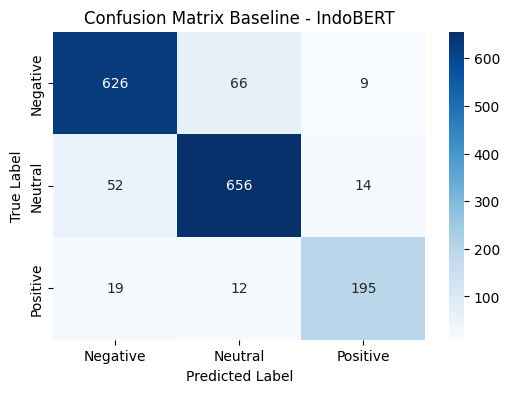

In [15]:
# ==========================================
# Testing & Evaluasi Akhir
# ==========================================
print("\n--- Evaluasi Akhir pada Data Test ---")
model.eval()
y_true_indobert, y_pred_indobert = [], []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
        logits = outputs.logits

    preds = torch.argmax(logits, dim=1).flatten().cpu().numpy()
    labels = batch['labels'].flatten().cpu().numpy()

    y_pred_indobert.extend(preds)
    y_true_indobert.extend(labels)

print("\nClassification Report IndoBERT Baseline:")
print(classification_report(y_true_indobert, y_pred_indobert, target_names=unique_labels))
evaluate_metrics(y_true_indobert, y_pred_indobert)
plot_confusion_matrix_with_labels(y_true_indobert, y_pred_indobert, labels=unique_labels, title=f"Confusion Matrix Baseline - {model_name}")

In [16]:
# ==========================================
# Simpan Model
# ==========================================
save_path = f"/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_{model_name}"
model.save_pretrained(save_path)
tokenizers[model_name].save_pretrained(save_path)
print(f"Model dan Tokenizer disimpan di: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan Tokenizer disimpan di: /content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_IndoBERT


## Modified IndoBERT

In [17]:
# ==========================================
# IndoBERT Setup
# ==========================================
model_name = "IndoBERT"
print(f"=== Memulai Training untuk {model_name} ===")

config = AutoConfig.from_pretrained(
    model_paths[model_name],
    num_labels=NUM_LABELS,
    hidden_dropout_prob=0.1,              # dropout di layer utama
    attention_probs_dropout_prob=0.1      # dropout di attention
)

# Buat DataLoader
train_dataset = SentimentDataset(tokenized_inputs[model_name]['train'], train_labels_encoded)
val_dataset = SentimentDataset(tokenized_inputs[model_name]['val'], val_labels_encoded)
test_dataset = SentimentDataset(tokenized_inputs[model_name]['test'], test_labels_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Inisialisasi Model
model = AutoModelForSequenceClassification.from_pretrained(
    model_paths[model_name],
    config=config
)
model.to(device) # Pindahkan model ke device (GPU/CPU)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

=== Memulai Training untuk IndoBERT ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
# ==========================================
# PERSIAPAN SEBELUM LOOP
# ==========================================
# Lists to store metrics for plotting
train_losses_indobert_modified = []
val_losses_indobert_modified = []
train_accuracies_indobert_modified = []
val_accuracies_indobert_modified = []

# Lists untuk menyimpan probabilitas epoch terakhir demi kurva ROC
final_val_probs_indobert_modified = []
final_val_labels_indobert_modified = []

early_stopping = EarlyStopping(patience=3, path='/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indobert_model_modified.pth')

# Training Loop
for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0

    # Wrap train_loader with tqdm for progress bar
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    for batch in train_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten() # Ambil label

        model.zero_grad()

        # Forward pass
        outputs = model(**batch)
        logits = outputs.logits

        # Hitung loss menggunakan criterion berbobot
        loss = criterion(logits, labels)

        total_train_loss += loss.item()

        # Hitung akurasi pada saat training
        preds = torch.argmax(logits, dim=1).flatten()
        total_train_accuracy += (preds == labels).cpu().numpy().mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_accuracy / len(train_loader)

    train_losses_indobert_modified.append(avg_train_loss)
    train_accuracies_indobert_modified.append(avg_train_accuracy)

    # ==========================================
    # VALIDATION PHASE
    # ==========================================
    model.eval()
    total_val_loss, total_val_accuracy = 0, 0

    # List sementara untuk ROC di epoch saat ini
    current_val_probs = []
    current_val_labels = []

    # Wrap val_loader with tqdm for progress bar
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Validation")
    for batch in val_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten()

        with torch.no_grad():
            outputs = model(**batch)
            logits = outputs.logits

            # Gunakan criterion yang sama untuk validasi
            loss = criterion(logits, labels)

        total_val_loss += loss.item()
        preds = torch.argmax(logits, dim=1).flatten()
        total_val_accuracy += (preds == labels).cpu().numpy().mean()

        # Ambil probabilitas untuk kelas positif (indeks 1) untuk ROC/AUC
        probs = F.softmax(logits, dim=1)
        current_val_probs.extend(probs.cpu().numpy()) # Menyimpan array multi-dimensi
        current_val_labels.extend(labels.cpu().numpy())

        val_loop.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_accuracy / len(val_loader)

    val_losses_indobert_modified.append(avg_val_loss)
    val_accuracies_indobert_modified.append(avg_val_accuracy)

    # Simpan hasil prediksi validasi hanya dari epoch terakhir untuk digambar di ROC
    final_val_probs_indobert_modified = current_val_probs
    final_val_labels_indobert_modified = current_val_labels

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

    # ==========================================
    # [TAMBAHAN BARU] CEK EARLY STOPPING DI AKHIR EPOCH
    # ==========================================
    early_stopping(avg_val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.")
        break # Keluar dari loop training

# ==========================================
# LOAD MODEL TERBAIK SETELAH TRAINING SELESAI
# ==========================================
print("\nMemuat (loading) kembali bobot model terbaik...")
model.load_state_dict(torch.load('/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indobert_model_modified.pth'))
print("Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).")

Epoch 1/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.10it/s, loss=0.0147]


Epoch 1/5 | Train Loss: 0.5922 | Train Acc: 0.7403 | Val Loss: 0.3862 | Val Acc: 0.8732
Validation loss menurun. Model disimpan!


Epoch 2/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.03it/s, loss=0.00332]


Epoch 2/5 | Train Loss: 0.2316 | Train Acc: 0.9146 | Val Loss: 0.3395 | Val Acc: 0.9008
Validation loss menurun. Model disimpan!


Epoch 3/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.05it/s, loss=0.000817]


Epoch 3/5 | Train Loss: 0.1168 | Train Acc: 0.9613 | Val Loss: 0.4083 | Val Acc: 0.9020
EarlyStopping counter: 1 out of 3


Epoch 4/5 Validation: 100%|██████████| 104/104 [00:13<00:00,  8.00it/s, loss=0.000372]


Epoch 4/5 | Train Loss: 0.0626 | Train Acc: 0.9809 | Val Loss: 0.4814 | Val Acc: 0.9129
EarlyStopping counter: 2 out of 3


Epoch 5/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.04it/s, loss=0.000301]


Epoch 5/5 | Train Loss: 0.0324 | Train Acc: 0.9912 | Val Loss: 0.5131 | Val Acc: 0.9147
EarlyStopping counter: 3 out of 3
Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.

Memuat (loading) kembali bobot model terbaik...
Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).



--- Evaluasi Akhir pada Data Test ---

Classification Report IndoBERT Modified:
              precision    recall  f1-score   support

    Negative       0.92      0.87      0.89       701
     Neutral       0.87      0.94      0.91       722
    Positive       0.94      0.89      0.92       226

    accuracy                           0.90      1649
   macro avg       0.91      0.90      0.90      1649
weighted avg       0.90      0.90      0.90      1649

Accuracy  : 0.9018
F1 Score  : 0.9048
Precision : 0.9130
Recall    : 0.8986


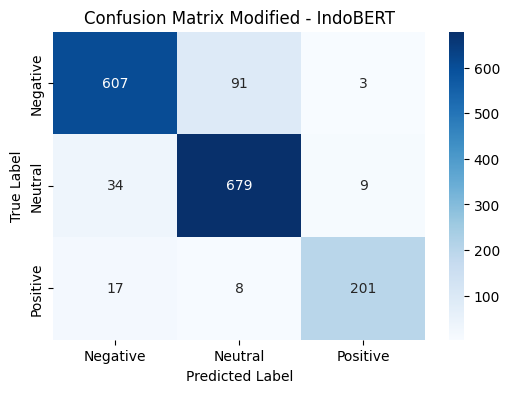

In [19]:
# ==========================================
# Testing & Evaluasi Akhir
# ==========================================
print("\n--- Evaluasi Akhir pada Data Test ---")
model.eval()
y_true_indobert_modified, y_pred_indobert_modified = [], []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
        logits = outputs.logits

    preds = torch.argmax(logits, dim=1).flatten().cpu().numpy()
    labels = batch['labels'].flatten().cpu().numpy()

    y_pred_indobert_modified.extend(preds)
    y_true_indobert_modified.extend(labels)

print("\nClassification Report IndoBERT Modified:")
print(classification_report(y_true_indobert_modified, y_pred_indobert_modified, target_names=unique_labels))
evaluate_metrics(y_true_indobert_modified, y_pred_indobert_modified)
plot_confusion_matrix_with_labels(y_true_indobert_modified, y_pred_indobert_modified, labels=unique_labels, title=f"Confusion Matrix Modified - {model_name}")

In [20]:
# ==========================================
# Simpan Model
# ==========================================
save_path = f"/content/drive/MyDrive/Kuliah/Jurnal/saved_model_{model_name}"
model.save_pretrained(save_path)
tokenizers[model_name].save_pretrained(save_path)
print(f"Model dan Tokenizer disimpan di: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan Tokenizer disimpan di: /content/drive/MyDrive/Kuliah/Jurnal/saved_model_IndoBERT


# IndoRoBERTa

## Baseline IndoRoBERTa

In [21]:
# ==========================================
# IndoRoBERTa Setup
# ==========================================
model_name = "IndoRoBERTa"
print(f"=== Memulai Training untuk {model_name} ===")

# Buat DataLoader
train_dataset = SentimentDataset(tokenized_inputs[model_name]['train'], train_labels_encoded)
val_dataset = SentimentDataset(tokenized_inputs[model_name]['val'], val_labels_encoded)
test_dataset = SentimentDataset(tokenized_inputs[model_name]['test'], test_labels_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Inisialisasi Model
model = AutoModelForSequenceClassification.from_pretrained(model_paths[model_name], num_labels=NUM_LABELS)
model.to(device)

# Hanya optimalkan parameter yang tidak dibekukan (requires_grad=True)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

=== Memulai Training untuk IndoRoBERTa ===


pytorch_model.bin:   0%|          | 0.00/507M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cahya/roberta-base-indonesian-522M
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
# ==========================================
# Training Loop IndoRoBERTa
# ==========================================
# Lists to store metrics for plotting
train_losses_indoroberta = []
val_losses_indoroberta = []
train_accuracies_indoroberta = []
val_accuracies_indoroberta = []

# Lists untuk menyimpan probabilitas epoch terakhir demi kurva ROC
final_val_probs_indoroberta = []
final_val_labels_indoroberta = []

# [TAMBAHAN BARU] Inisialisasi Early Stopping for IndoRoBERTa
early_stopping_roberta = EarlyStopping(patience=3, path='/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indoroberta_model_baseline.pth')

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    for batch in train_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten() # Ambil label

        model.zero_grad()
        outputs = model(**batch)

        # logits = outputs.logits # Ambil logits untuk perhitungan akurasi
        # Hitung loss menggunakan loss bawaan dari model
        loss = outputs.loss
        total_train_loss += loss.item()

        # Hitung akurasi pada saat training
        preds = torch.argmax(outputs.logits, dim=1).flatten()
        total_train_accuracy += (preds == labels).cpu().numpy().mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_accuracy / len(train_loader) #

    train_losses_indoroberta.append(avg_train_loss)
    train_accuracies_indoroberta.append(avg_train_accuracy) #

    # Validation
    model.eval()
    total_val_loss, total_val_accuracy = 0, 0

    # List sementara untuk ROC di epoch saat ini
    current_val_probs = []
    current_val_labels = []

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Validation")
    for batch in val_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten()

        with torch.no_grad():
            outputs = model(**batch)
            # logits = outputs.logits
            # Gunakan loss bawaan dari model untuk validasi
            loss = outputs.loss

        total_val_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1).flatten()
        total_val_accuracy += (preds == labels).cpu().numpy().mean()

        # Ambil probabilitas untuk ROC/AUC
        probs = F.softmax(outputs.logits, dim=1)
        current_val_probs.extend(probs.cpu().numpy())
        current_val_labels.extend(labels.cpu().numpy())

        val_loop.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_accuracy / len(val_loader)

    val_losses_indoroberta.append(avg_val_loss)
    val_accuracies_indoroberta.append(avg_val_accuracy)

    # Simpan hasil prediksi validasi hanya dari epoch terakhir untuk digambar di ROC
    final_val_probs_indoroberta = current_val_probs
    final_val_labels_indoroberta = current_val_labels

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

    # CEK EARLY STOPPING DI AKHIR EPOCH
    early_stopping_roberta(avg_val_loss, model)

    if early_stopping_roberta.early_stop:
        print("Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.")
        break # Keluar dari loop training

# ==========================================
# LOAD MODEL TERBAIK SETELAH TRAINING SELESAI
# ==========================================
print("\nMemuat (loading) kembali bobot model terbaik...")
model.load_state_dict(torch.load('/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indoroberta_model_baseline.pth'))
print("Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).")

Epoch 1/5 Training:   0%|          | 1/481 [00:00<03:38,  2.20it/s, loss=1.11]

model.safetensors:   0%|          | 0.00/507M [00:00<?, ?B/s]

Epoch 1/5 Validation: 100%|██████████| 104/104 [00:11<00:00,  8.98it/s, loss=0.0484]


Epoch 1/5 | Train Loss: 0.6547 | Train Acc: 0.7292 | Val Loss: 0.4249 | Val Acc: 0.8456
Validation loss menurun. Model disimpan!


Epoch 2/5 Validation: 100%|██████████| 104/104 [00:11<00:00,  8.98it/s, loss=0.0092]


...

Epoch 3/5 | Train Loss: 0.2450 | Train Acc: 0.9153 | Val Loss: 0.3636 | Val Acc: 0.8822
EarlyStopping counter: 1 out of 3


Epoch 4/5 Validation: 100%|██████████| 104/104 [00:11<00:00,  8.95it/s, loss=0.00146]


Epoch 4/5 | Train Loss: 0.1761 | Train Acc: 0.9420 | Val Loss: 0.4073 | Val Acc: 0.8816
EarlyStopping counter: 2 out of 3


Epoch 5/5 Validation: 100%|██████████| 104/104 [00:11<00:00,  8.98it/s, loss=0.00112]


Epoch 5/5 | Train Loss: 0.1359 | Train Acc: 0.9582 | Val Loss: 0.4378 | Val Acc: 0.8834
EarlyStopping counter: 3 out of 3
Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.

Memuat (loading) kembali bobot model terbaik...
Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).



--- Evaluasi Akhir pada Data Test ---

Classification Report IndoRoBERTa Baseline:
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86       701
     Neutral       0.87      0.89      0.88       722
    Positive       0.89      0.77      0.82       226

    accuracy                           0.86      1649
   macro avg       0.87      0.84      0.85      1649
weighted avg       0.87      0.86      0.86      1649

Accuracy  : 0.8648
F1 Score  : 0.8550
Precision : 0.8713
Recall    : 0.8421


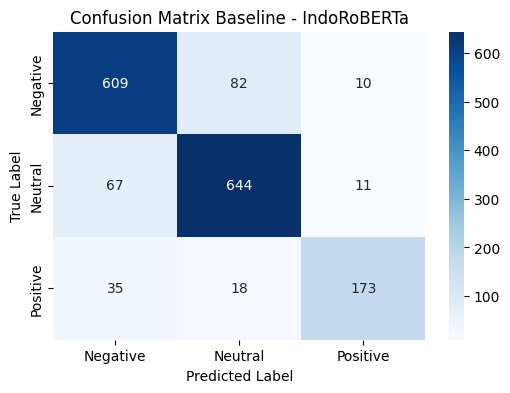

In [23]:
# ==========================================
# Testing & Evaluasi Akhir
# ==========================================
print("\n--- Evaluasi Akhir pada Data Test ---")
model.eval()
y_true_roberta, y_pred_roberta = [], []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
        logits = outputs.logits

    preds = torch.argmax(logits, dim=1).flatten().cpu().numpy()
    labels = batch['labels'].flatten().cpu().numpy()

    y_pred_roberta.extend(preds)
    y_true_roberta.extend(labels)

print("\nClassification Report IndoRoBERTa Baseline:")
print(classification_report(y_true_roberta, y_pred_roberta, target_names=unique_labels))
evaluate_metrics(y_true_roberta, y_pred_roberta)
plot_confusion_matrix_with_labels(y_true_roberta, y_pred_roberta, labels=unique_labels, title=f"Confusion Matrix Baseline - {model_name}")

In [24]:
# ==========================================
# Simpan Model
# ==========================================
save_path = f"/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_{model_name}"
model.save_pretrained(save_path)
tokenizers[model_name].save_pretrained(save_path)
print(f"Model dan Tokenizer disimpan di: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan Tokenizer disimpan di: /content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_IndoRoBERTa


## Modified IndoRoBERTa

In [25]:
# ==========================================
# IndoRoBERTa Setup
# ==========================================
model_name = "IndoRoBERTa"
print(f"=== Memulai Training untuk {model_name} ===")

config = AutoConfig.from_pretrained(
    model_paths[model_name],
    num_labels=NUM_LABELS,
    hidden_dropout_prob=0.1,              # dropout di layer utama
    attention_probs_dropout_prob=0.1      # dropout di attention
)

# Buat DataLoader
train_dataset = SentimentDataset(tokenized_inputs[model_name]['train'], train_labels_encoded)
val_dataset = SentimentDataset(tokenized_inputs[model_name]['val'], val_labels_encoded)
test_dataset = SentimentDataset(tokenized_inputs[model_name]['test'], test_labels_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Inisialisasi Model
model = AutoModelForSequenceClassification.from_pretrained(
    model_paths[model_name],
    config=config
)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

=== Memulai Training untuk IndoRoBERTa ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cahya/roberta-base-indonesian-522M
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
# ==========================================
# Training Loop IndoRoBERTa
# ==========================================
# Lists to store metrics for plotting
train_losses_indoroberta_modified = []
val_losses_indoroberta_modified = []
train_accuracies_indoroberta_modified = []
val_accuracies_indoroberta_modified = []

# Lists untuk menyimpan probabilitas epoch terakhir demi kurva ROC
final_val_probs_indoroberta_modified = []
final_val_labels_indoroberta_modified = []

# [TAMBAHAN BARU] Inisialisasi Early Stopping for IndoRoBERTa
early_stopping_roberta = EarlyStopping(patience=3, path='/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indoroberta_model_modified.pth')

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    for batch in train_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten() # Ambil label

        model.zero_grad()
        outputs = model(**batch)

        logits = outputs.logits # Ambil logits untuk perhitungan akurasi
        # Hitung loss menggunakan criterion berbobot yang kita buat
        loss = criterion(logits, labels)
        total_train_loss += loss.item()

        # Hitung akurasi pada saat training
        preds = torch.argmax(logits, dim=1).flatten()
        total_train_accuracy += (preds == labels).cpu().numpy().mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_accuracy / len(train_loader) #

    train_losses_indoroberta_modified.append(avg_train_loss)
    train_accuracies_indoroberta_modified.append(avg_train_accuracy) #

    # Validation
    model.eval()
    total_val_loss, total_val_accuracy = 0, 0

    # List sementara untuk ROC di epoch saat ini
    current_val_probs = []
    current_val_labels = []

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Validation")
    for batch in val_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten()

        with torch.no_grad():
            outputs = model(**batch)
            logits = outputs.logits
            # Gunakan criterion yang sama untuk validasi
            loss = criterion(logits, labels)

        total_val_loss += loss.item()
        preds = torch.argmax(logits, dim=1).flatten()
        total_val_accuracy += (preds == labels).cpu().numpy().mean()

        # Ambil probabilitas untuk ROC/AUC
        probs = F.softmax(logits, dim=1)
        current_val_probs.extend(probs.cpu().numpy())
        current_val_labels.extend(labels.cpu().numpy())

        val_loop.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_accuracy / len(val_loader)

    val_losses_indoroberta_modified.append(avg_val_loss)
    val_accuracies_indoroberta_modified.append(avg_val_accuracy)

    # Simpan hasil prediksi validasi hanya dari epoch terakhir untuk digambar di ROC
    final_val_probs_indoroberta_modified = current_val_probs
    final_val_labels_indoroberta_modified = current_val_labels

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

    # CEK EARLY STOPPING DI AKHIR EPOCH
    early_stopping_roberta(avg_val_loss, model)

    if early_stopping_roberta.early_stop:
        print("Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.")
        break # Keluar dari loop training

# ==========================================
# LOAD MODEL TERBAIK SETELAH TRAINING SELESAI
# ==========================================
print("\nMemuat (loading) kembali bobot model terbaik...")
model.load_state_dict(torch.load('/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indoroberta_model_modified.pth'))
print("Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).")

Epoch 1/5 Validation: 100%|██████████| 104/104 [00:11<00:00,  9.01it/s, loss=0.0507]


Epoch 1/5 | Train Loss: 0.7450 | Train Acc: 0.6746 | Val Loss: 0.4742 | Val Acc: 0.8444
Validation loss menurun. Model disimpan!


Epoch 2/5 Validation: 100%|██████████| 104/104 [00:11<00:00,  9.02it/s, loss=0.00704]


Epoch 2/5 | Train Loss: 0.3689 | Train Acc: 0.8679 | Val Loss: 0.4040 | Val Acc: 0.8678
Validation loss menurun. Model disimpan!


Epoch 3/5 Validation: 100%|██████████| 104/104 [00:11<00:00,  8.99it/s, loss=0.00396]


Epoch 3/5 | Train Loss: 0.2624 | Train Acc: 0.9127 | Val Loss: 0.4789 | Val Acc: 0.8648
EarlyStopping counter: 1 out of 3


Epoch 4/5 Validation: 100%|██████████| 104/104 [00:11<00:00,  9.00it/s, loss=0.0027]


Epoch 4/5 | Train Loss: 0.1938 | Train Acc: 0.9350 | Val Loss: 0.4592 | Val Acc: 0.8810
EarlyStopping counter: 2 out of 3


Epoch 5/5 Validation: 100%|██████████| 104/104 [00:11<00:00,  9.01it/s, loss=0.00205]


Epoch 5/5 | Train Loss: 0.1525 | Train Acc: 0.9505 | Val Loss: 0.4911 | Val Acc: 0.8876
EarlyStopping counter: 3 out of 3
Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.

Memuat (loading) kembali bobot model terbaik...
Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).



--- Evaluasi Akhir pada Data Test ---

Classification Report IndoRoBERTa Modified:
              precision    recall  f1-score   support

    Negative       0.87      0.80      0.83       701
     Neutral       0.82      0.91      0.87       722
    Positive       0.89      0.81      0.85       226

    accuracy                           0.85      1649
   macro avg       0.86      0.84      0.85      1649
weighted avg       0.85      0.85      0.85      1649

Accuracy  : 0.8496
F1 Score  : 0.8490
Precision : 0.8605
Recall    : 0.8410


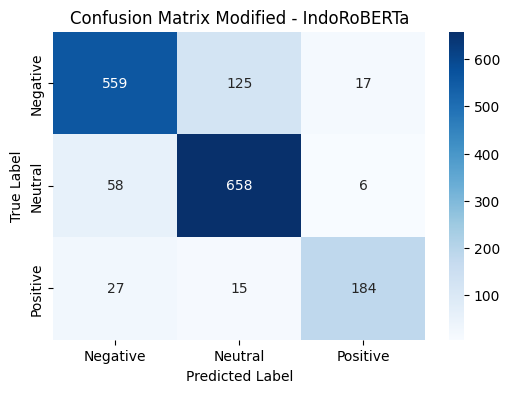

In [27]:
# ==========================================
# Testing & Evaluasi Akhir
# ==========================================
print("\n--- Evaluasi Akhir pada Data Test ---")
model.eval()
y_true_roberta_modified, y_pred_roberta_modified = [], []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
        logits = outputs.logits

    preds = torch.argmax(logits, dim=1).flatten().cpu().numpy()
    labels = batch['labels'].flatten().cpu().numpy()

    y_pred_roberta_modified.extend(preds)
    y_true_roberta_modified.extend(labels)

print("\nClassification Report IndoRoBERTa Modified:")
print(classification_report(y_true_roberta_modified, y_pred_roberta_modified, target_names=unique_labels))
evaluate_metrics(y_true_roberta_modified, y_pred_roberta_modified)
plot_confusion_matrix_with_labels(y_true_roberta_modified, y_pred_roberta_modified, labels=unique_labels, title=f"Confusion Matrix Modified - {model_name}")

In [28]:
# ==========================================
# Simpan Model
# ==========================================
save_path = f"/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_{model_name}"
model.save_pretrained(save_path)
tokenizers[model_name].save_pretrained(save_path)
print(f"Model dan Tokenizer disimpan di: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan Tokenizer disimpan di: /content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_IndoRoBERTa


# IndoBERTweet

## Baseline IndoBERTweet

In [29]:
# ==========================================
# indoBERTweet Setup
# ==========================================
model_name = "indoBERTweet"
print(f"=== Memulai Training untuk {model_name} ===")

# Buat DataLoader
train_dataset = SentimentDataset(tokenized_inputs[model_name]['train'], train_labels_encoded)
val_dataset = SentimentDataset(tokenized_inputs[model_name]['val'], val_labels_encoded)
test_dataset = SentimentDataset(tokenized_inputs[model_name]['test'], test_labels_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Inisialisasi Model
model = AutoModelForSequenceClassification.from_pretrained(model_paths[model_name], num_labels=NUM_LABELS)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

=== Memulai Training untuk indoBERTweet ===


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
# ==========================================
# Training Loop indoBERTweet
# ==========================================
# Lists to store metrics for plotting
train_losses_indobertweet = []
val_losses_indobertweet = []
train_accuracies_indobertweet = []
val_accuracies_indobertweet = []

# Lists untuk menyimpan probabilitas epoch terakhir demi kurva ROC
final_val_probs_indobertweet = []
final_val_labels_indobertweet = []

# Inisialisasi Early Stopping for indoBERTweet
early_stopping_indobertweet = EarlyStopping(patience=3, path='/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indobertweet_model_baseline.pth')

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0 #

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    for batch in train_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten() # Ambil label

        model.zero_grad()
        outputs = model(**batch)

        # logits = outputs.logits # Ambil logits untuk perhitungan akurasi
        loss = outputs.loss # Menggunakan loss bawaan dari model
        total_train_loss += loss.item()

        # Hitung akurasi pada saat training
        preds = torch.argmax(outputs.logits, dim=1).flatten()
        total_train_accuracy += (preds == labels).cpu().numpy().mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_accuracy / len(train_loader) # [TAMBAHAN]

    train_losses_indobertweet.append(avg_train_loss)
    train_accuracies_indobertweet.append(avg_train_accuracy) # [TAMBAHAN]

    # Validation
    model.eval()
    total_val_loss, total_val_accuracy = 0, 0

    # List sementara untuk ROC di epoch saat ini
    current_val_probs = []
    current_val_labels = []

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Validation")
    for batch in val_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten()

        with torch.no_grad():
            outputs = model(**batch)
            # logits = outputs.logits
            loss = outputs.loss # Menggunakan loss bawaan dari model

        total_val_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1).flatten()
        total_val_accuracy += (preds == labels).cpu().numpy().mean()

        # Ambil probabilitas seluruh kelas untuk ROC/AUC
        probs = F.softmax(outputs.logits, dim=1)
        current_val_probs.extend(probs.cpu().numpy())
        current_val_labels.extend(labels.cpu().numpy())

        val_loop.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_accuracy / len(val_loader)

    val_losses_indobertweet.append(avg_val_loss)
    val_accuracies_indobertweet.append(avg_val_accuracy)

    # Simpan hasil prediksi validasi hanya dari epoch terakhir untuk digambar di ROC
    final_val_probs_indobertweet = current_val_probs
    final_val_labels_indobertweet = current_val_labels

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

    # ==========================================
    # CEK EARLY STOPPING DI AKHIR EPOCH
    # ==========================================
    early_stopping_indobertweet(avg_val_loss, model)

    if early_stopping_indobertweet.early_stop:
        print("Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.")
        break # Keluar dari loop training

# ==========================================
# LOAD MODEL TERBAIK SETELAH TRAINING SELESAI
# ==========================================
print("\nMemuat (loading) kembali bobot model terbaik...")
model.load_state_dict(torch.load('/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indobertweet_model_baseline.pth'))
print("Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).")

Epoch 1/5 Training:   0%|          | 2/481 [00:00<02:55,  2.72it/s, loss=1.22]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Epoch 1/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.10it/s, loss=0.204]


Epoch 1/5 | Train Loss: 0.8344 | Train Acc: 0.6232 | Val Loss: 0.6528 | Val Acc: 0.7224
Validation loss menurun. Model disimpan!


Epoch 2/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.11it/s, loss=0.0171]


...

Epoch 3/5 | Train Loss: 0.3067 | Train Acc: 0.8872 | Val Loss: 0.3696 | Val Acc: 0.8696
Validation loss menurun. Model disimpan!


Epoch 4/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.09it/s, loss=0.00243]


Epoch 4/5 | Train Loss: 0.2197 | Train Acc: 0.9193 | Val Loss: 0.3684 | Val Acc: 0.8876
Validation loss menurun. Model disimpan!


Epoch 5/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.09it/s, loss=0.00201]


Epoch 5/5 | Train Loss: 0.1775 | Train Acc: 0.9367 | Val Loss: 0.3718 | Val Acc: 0.8900
EarlyStopping counter: 1 out of 3

Memuat (loading) kembali bobot model terbaik...
Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).



--- Evaluasi Akhir pada Data Test ---

Classification Report IndoBERTweet Baseline:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87       701
     Neutral       0.86      0.90      0.88       722
    Positive       0.93      0.83      0.88       226

    accuracy                           0.88      1649
   macro avg       0.89      0.87      0.88      1649
weighted avg       0.88      0.88      0.88      1649

Accuracy  : 0.8763
F1 Score  : 0.8762
Precision : 0.8884
Recall    : 0.8660


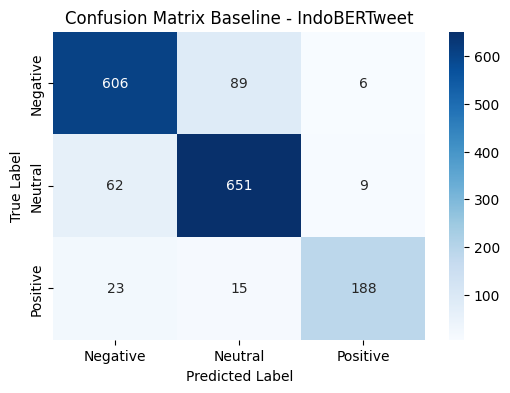

In [31]:
# ==========================================
# Testing & Evaluasi Akhir
# ==========================================
print("\n--- Evaluasi Akhir pada Data Test ---")
model.eval()
y_true_indobertweet, y_pred_indobertweet = [], []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
        logits = outputs.logits

    preds = torch.argmax(logits, dim=1).flatten().cpu().numpy()
    labels = batch['labels'].flatten().cpu().numpy()

    y_pred_indobertweet.extend(preds)
    y_true_indobertweet.extend(labels)

print("\nClassification Report IndoBERTweet Baseline:")
print(classification_report(y_true_indobertweet, y_pred_indobertweet, target_names=unique_labels))
evaluate_metrics(y_true_indobertweet, y_pred_indobertweet)
plot_confusion_matrix_with_labels(y_true_indobertweet, y_pred_indobertweet, labels=unique_labels, title="Confusion Matrix Baseline - IndoBERTweet")

In [32]:
# ==========================================
# Simpan Model
# ==========================================
save_path = f"/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_{model_name}"
model.save_pretrained(save_path)
tokenizers[model_name].save_pretrained(save_path)
print(f"Model dan Tokenizer disimpan di: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan Tokenizer disimpan di: /content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_indoBERTweet


## Modified IndoBERTweet

In [33]:
# ==========================================
# indoBERTweet Setup
# ==========================================
model_name = "indoBERTweet"
print(f"=== Memulai Training untuk {model_name} ===")

config = AutoConfig.from_pretrained(
    model_paths[model_name],
    num_labels=NUM_LABELS,
    hidden_dropout_prob=0.1,              # dropout di layer utama
    attention_probs_dropout_prob=0.1      # dropout di attention
)

# Buat DataLoader
train_dataset = SentimentDataset(tokenized_inputs[model_name]['train'], train_labels_encoded)
val_dataset = SentimentDataset(tokenized_inputs[model_name]['val'], val_labels_encoded)
test_dataset = SentimentDataset(tokenized_inputs[model_name]['test'], test_labels_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Inisialisasi Model
model = AutoModelForSequenceClassification.from_pretrained(
    model_paths[model_name],
    config=config
)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

=== Memulai Training untuk indoBERTweet ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [34]:
# ==========================================
# Training Loop indoBERTweet
# ==========================================
# Lists to store metrics for plotting
train_losses_indobertweet_modified = []
val_losses_indobertweet_modified = []
train_accuracies_indobertweet_modified = []
val_accuracies_indobertweet_modified = []

# Lists untuk menyimpan probabilitas epoch terakhir demi kurva ROC
final_val_probs_indobertweet_modified = []
final_val_labels_indobertweet_modified = []

# Inisialisasi Early Stopping for indoBERTweet
early_stopping_indobertweet = EarlyStopping(patience=3, path='/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indobertweet_model_modified.pth')

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0 #

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    for batch in train_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten() # Ambil label

        model.zero_grad()
        outputs = model(**batch)

        logits = outputs.logits # Ambil logits untuk perhitungan akurasi
        loss = criterion(logits, labels) # Menggunakan criterion berbobot
        total_train_loss += loss.item()

        # Hitung akurasi pada saat training
        preds = torch.argmax(logits, dim=1).flatten()
        total_train_accuracy += (preds == labels).cpu().numpy().mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_accuracy / len(train_loader) # [TAMBAHAN]

    train_losses_indobertweet_modified.append(avg_train_loss)
    train_accuracies_indobertweet_modified.append(avg_train_accuracy) # [TAMBAHAN]

    # Validation
    model.eval()
    total_val_loss, total_val_accuracy = 0, 0

    # List sementara untuk ROC di epoch saat ini
    current_val_probs = []
    current_val_labels = []

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Validation")
    for batch in val_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten()

        with torch.no_grad():
            outputs = model(**batch)
            logits = outputs.logits
            loss = criterion(logits, labels) # Menggunakan criterion berbobot

        total_val_loss += loss.item()
        preds = torch.argmax(logits, dim=1).flatten()
        total_val_accuracy += (preds == labels).cpu().numpy().mean()

        # Ambil probabilitas seluruh kelas untuk ROC/AUC
        probs = F.softmax(logits, dim=1)
        current_val_probs.extend(probs.cpu().numpy())
        current_val_labels.extend(labels.cpu().numpy())

        val_loop.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_accuracy / len(val_loader)

    val_losses_indobertweet_modified.append(avg_val_loss)
    val_accuracies_indobertweet_modified.append(avg_val_accuracy)

    # Simpan hasil prediksi validasi hanya dari epoch terakhir untuk digambar di ROC
    final_val_probs_indobertweet_modified = current_val_probs
    final_val_labels_indobertweet_modified = current_val_labels

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

    # ==========================================
    # CEK EARLY STOPPING DI AKHIR EPOCH
    # ==========================================
    early_stopping_indobertweet(avg_val_loss, model)

    if early_stopping_indobertweet.early_stop:
        print("Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.")
        break # Keluar dari loop training

# ==========================================
# LOAD MODEL TERBAIK SETELAH TRAINING SELESAI
# ==========================================
print("\nMemuat (loading) kembali bobot model terbaik...")
model.load_state_dict(torch.load('/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/best_indobertweet_model_modified.pth'))
print("Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).")

Epoch 1/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.08it/s, loss=0.348]


Epoch 1/5 | Train Loss: 0.9227 | Train Acc: 0.5813 | Val Loss: 0.6919 | Val Acc: 0.7001
Validation loss menurun. Model disimpan!


Epoch 2/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.12it/s, loss=0.0582]


Epoch 2/5 | Train Loss: 0.5182 | Train Acc: 0.7769 | Val Loss: 0.5059 | Val Acc: 0.8203
Validation loss menurun. Model disimpan!


Epoch 3/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.06it/s, loss=0.00771]


Epoch 3/5 | Train Loss: 0.3308 | Train Acc: 0.8701 | Val Loss: 0.4315 | Val Acc: 0.8540
Validation loss menurun. Model disimpan!


Epoch 4/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.06it/s, loss=0.00424]


Epoch 4/5 | Train Loss: 0.2458 | Train Acc: 0.9038 | Val Loss: 0.4084 | Val Acc: 0.8684
Validation loss menurun. Model disimpan!


Epoch 5/5 Validation: 100%|██████████| 104/104 [00:12<00:00,  8.10it/s, loss=0.00332]


Epoch 5/5 | Train Loss: 0.2010 | Train Acc: 0.9254 | Val Loss: 0.4290 | Val Acc: 0.8702
EarlyStopping counter: 1 out of 3

Memuat (loading) kembali bobot model terbaik...
Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).



--- Evaluasi Akhir pada Data Test ---

Classification Report IndoBERTweet Modified:
              precision    recall  f1-score   support

    Negative       0.87      0.86      0.86       701
     Neutral       0.87      0.86      0.86       722
    Positive       0.85      0.91      0.88       226

    accuracy                           0.87      1649
   macro avg       0.86      0.88      0.87      1649
weighted avg       0.87      0.87      0.87      1649

Accuracy  : 0.8666
F1 Score  : 0.8692
Precision : 0.8625
Recall    : 0.8768


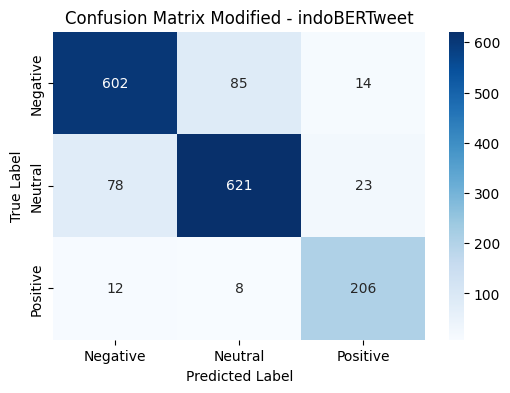

In [35]:
# ==========================================
# Testing & Evaluasi Akhir
# ==========================================
print("\n--- Evaluasi Akhir pada Data Test ---")
model.eval()
y_true_electra_modified, y_pred_electra_modified = [], []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
        logits = outputs.logits

    preds = torch.argmax(logits, dim=1).flatten().cpu().numpy()
    labels = batch['labels'].flatten().cpu().numpy()

    y_pred_electra_modified.extend(preds)
    y_true_electra_modified.extend(labels)

print("\nClassification Report IndoBERTweet Modified:")
print(classification_report(y_true_electra_modified, y_pred_electra_modified, target_names=unique_labels))
evaluate_metrics(y_true_electra_modified, y_pred_electra_modified)
plot_confusion_matrix_with_labels(y_true_electra_modified, y_pred_electra_modified, labels=unique_labels, title=f"Confusion Matrix Modified - {model_name}")

In [36]:
# ==========================================
# Simpan Model
# ==========================================
save_path = f"/content/drive/MyDrive/Kuliah/Jurnal/saved_model_{model_name}"
model.save_pretrained(save_path)
tokenizers[model_name].save_pretrained(save_path)
print(f"Model dan Tokenizer disimpan di: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan Tokenizer disimpan di: /content/drive/MyDrive/Kuliah/Jurnal/saved_model_indoBERTweet


# Evaluasi Training

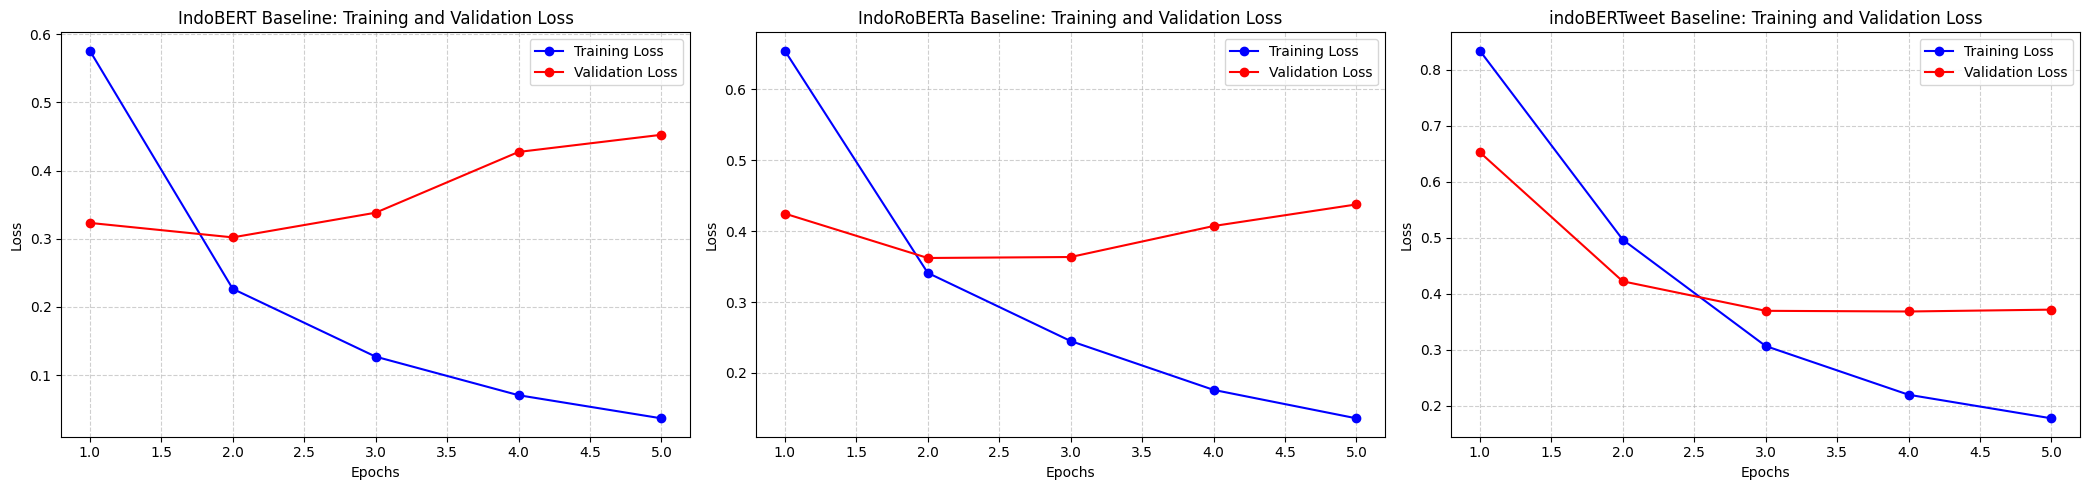

In [37]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots for Loss (1 row, 3 columns)
plt.figure(figsize=(21, 5))

# --- IndoBERT Loss Plot ---
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
actual_epochs_indobert = len(train_losses_indobert)
epochs_range_indobert = range(1, actual_epochs_indobert + 1)
plt.plot(epochs_range_indobert, train_losses_indobert, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range_indobert, val_losses_indobert, label='Validation Loss', marker='o', color='red')
plt.title('IndoBERT Baseline: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- IndoRoBERTa Loss Plot ---
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
actual_epochs_indoroberta = len(train_losses_indoroberta)
epochs_range_indoroberta = range(1, actual_epochs_indoroberta + 1)
plt.plot(epochs_range_indoroberta, train_losses_indoroberta, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range_indoroberta, val_losses_indoroberta, label='Validation Loss', marker='o', color='red')
plt.title('IndoRoBERTa Baseline: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- indoBERTweet Loss Plot ---
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
actual_epochs_indobertweet = len(train_losses_indobertweet)
epochs_range_indobertweet = range(1, actual_epochs_indobertweet + 1)
plt.plot(epochs_range_indobertweet, train_losses_indobertweet, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range_indobertweet, val_losses_indobertweet, label='Validation Loss', marker='o', color='red')
plt.title('indoBERTweet Baseline: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

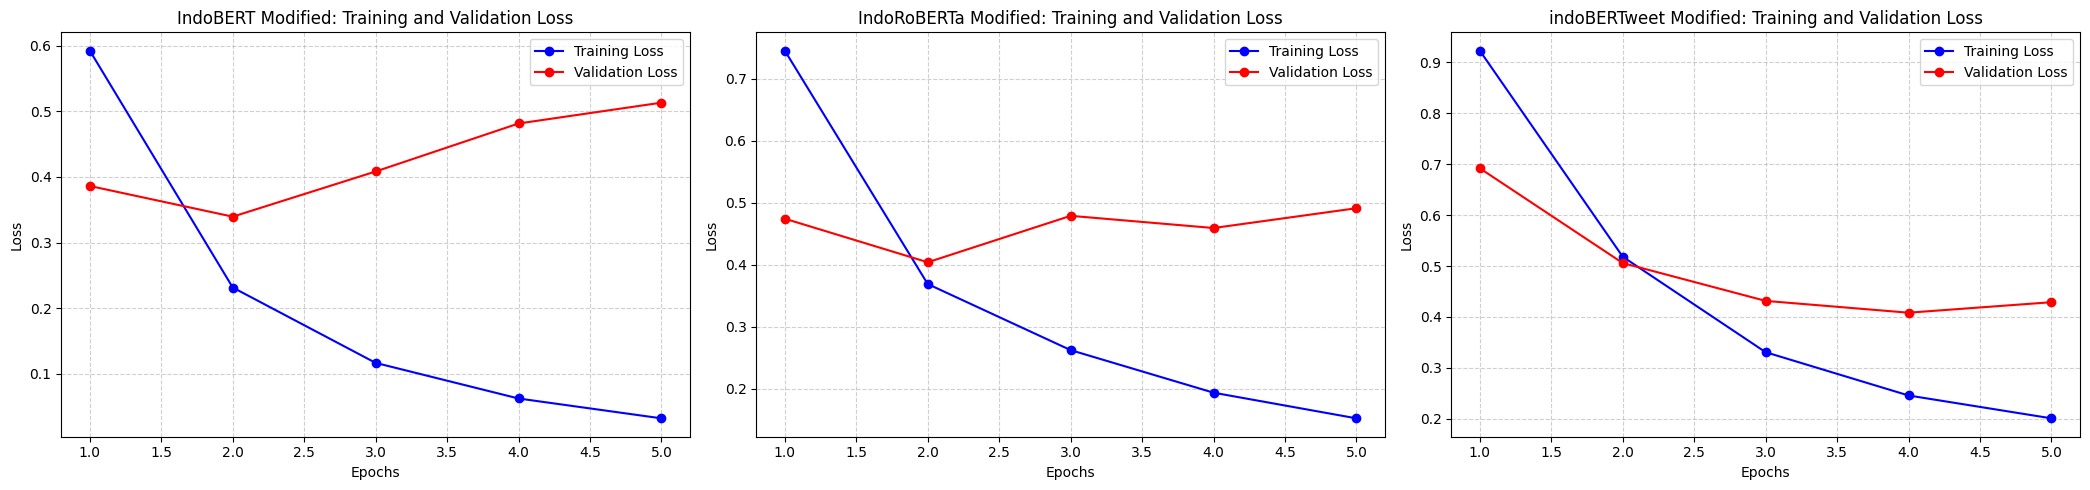

In [38]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots for Loss (1 row, 3 columns)
plt.figure(figsize=(21, 5))

# --- IndoBERT Loss Plot ---
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
actual_epochs_indobert_modified = len(train_losses_indobert_modified)
epochs_range_indobert_modified = range(1, actual_epochs_indobert_modified + 1)
plt.plot(epochs_range_indobert_modified, train_losses_indobert_modified, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range_indobert_modified, val_losses_indobert_modified, label='Validation Loss', marker='o', color='red')
plt.title('IndoBERT Modified: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- IndoRoBERTa Loss Plot ---
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
actual_epochs_indoroberta_modified = len(train_losses_indoroberta_modified)
epochs_range_indoroberta_modified = range(1, actual_epochs_indoroberta_modified + 1)
plt.plot(epochs_range_indoroberta_modified, train_losses_indoroberta_modified, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range_indoroberta_modified, val_losses_indoroberta_modified, label='Validation Loss', marker='o', color='red')
plt.title('IndoRoBERTa Modified: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- indoBERTweet Loss Plot ---
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
actual_epochs_indobertweet_modified = len(train_losses_indobertweet_modified)
epochs_range_indobertweet_modified = range(1, actual_epochs_indobertweet_modified + 1)
plt.plot(epochs_range_indobertweet_modified, train_losses_indobertweet_modified, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range_indobertweet_modified, val_losses_indobertweet_modified, label='Validation Loss', marker='o', color='red')
plt.title('indoBERTweet Modified: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

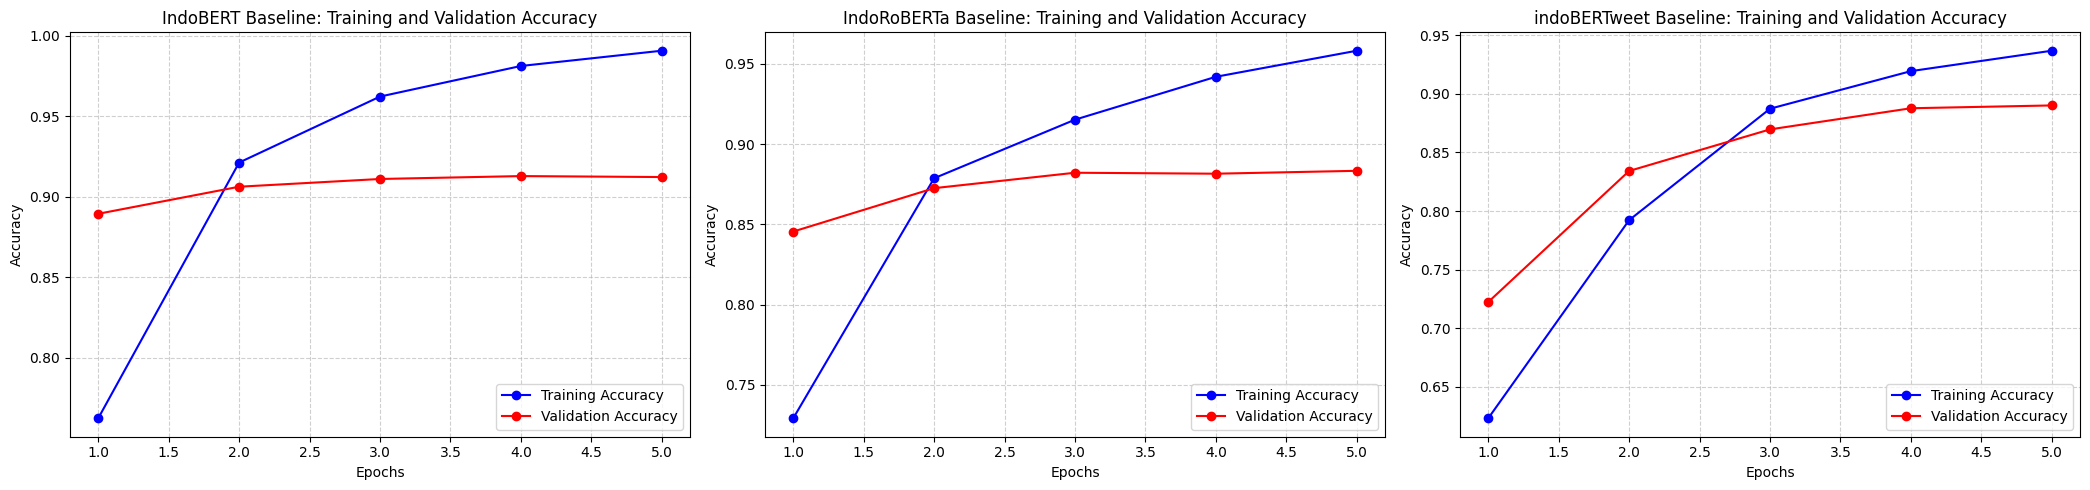

In [39]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots for Accuracy (1 row, 3 columns)
plt.figure(figsize=(21, 5))

# --- IndoBERT Accuracy Plot ---
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
actual_epochs_indobert = len(train_accuracies_indobert) # Re-using from previous cell
epochs_range_indobert = range(1, actual_epochs_indobert + 1)
plt.plot(epochs_range_indobert, train_accuracies_indobert, label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range_indobert, val_accuracies_indobert, label='Validation Accuracy', marker='o', color='red')
plt.title('IndoBERT Baseline: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- IndoRoBERTa Accuracy Plot ---
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
actual_epochs_indoroberta = len(train_accuracies_indoroberta) # Re-using from previous cell
epochs_range_indoroberta = range(1, actual_epochs_indoroberta + 1)
plt.plot(epochs_range_indoroberta, train_accuracies_indoroberta, label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range_indoroberta, val_accuracies_indoroberta, label='Validation Accuracy', marker='o', color='red')
plt.title('IndoRoBERTa Baseline: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- indoBERTweet Accuracy Plot ---
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
actual_epochs_indobertweet = len(train_accuracies_indobertweet) # Re-using from previous cell
epochs_range_indobertweet = range(1, actual_epochs_indobertweet + 1)
plt.plot(epochs_range_indobertweet, train_accuracies_indobertweet, label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range_indobertweet, val_accuracies_indobertweet, label='Validation Accuracy', marker='o', color='red')
plt.title('indoBERTweet Baseline: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

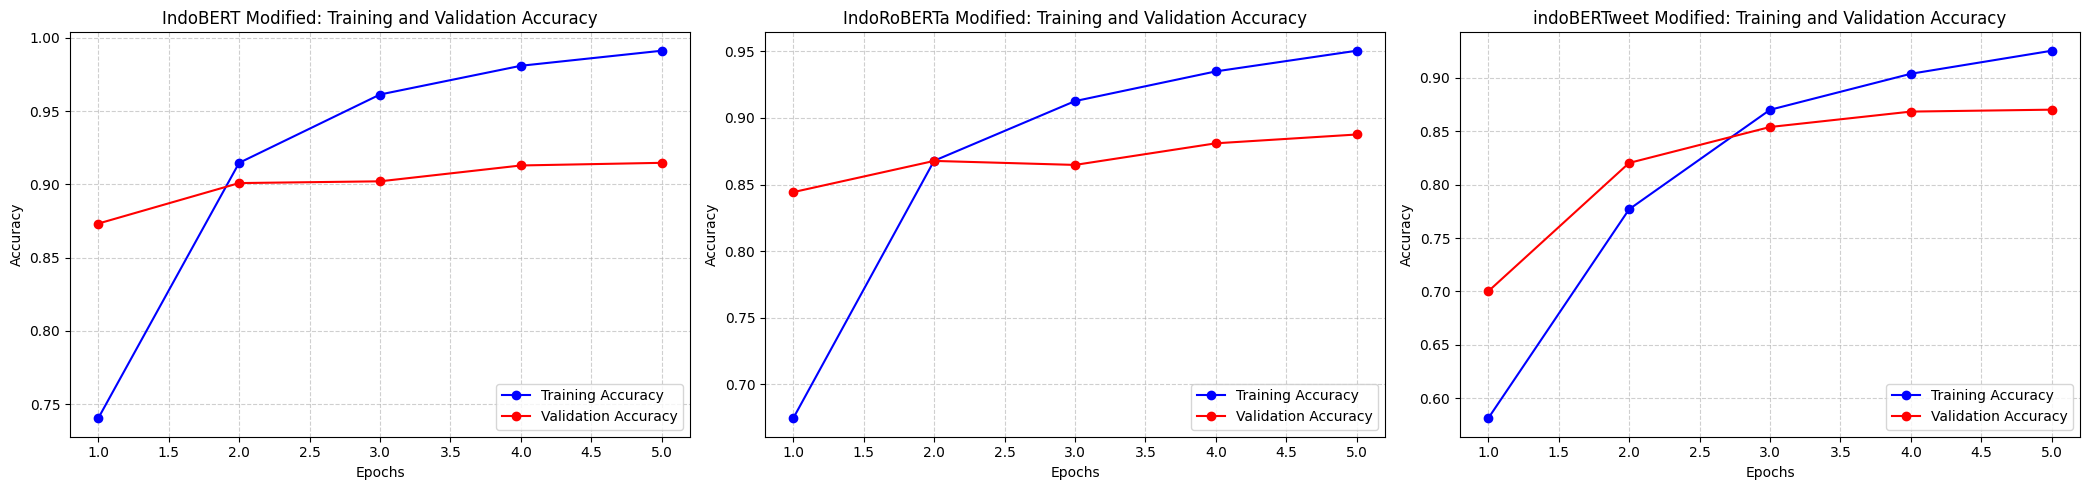

In [40]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots for Accuracy (1 row, 3 columns)
plt.figure(figsize=(21, 5))

# --- IndoBERT Accuracy Plot ---
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
actual_epochs_indobert_modified = len(train_accuracies_indobert_modified)
epochs_range_indobert_modified = range(1, actual_epochs_indobert_modified + 1)
plt.plot(epochs_range_indobert_modified, train_accuracies_indobert_modified, label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range_indobert_modified, val_accuracies_indobert_modified, label='Validation Accuracy', marker='o', color='red')
plt.title('IndoBERT Modified: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- IndoRoBERTa Accuracy Plot ---
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
actual_epochs_indoroberta_modified = len(train_accuracies_indoroberta_modified)
epochs_range_indoroberta_modified = range(1, actual_epochs_indoroberta_modified + 1)
plt.plot(epochs_range_indoroberta_modified, train_accuracies_indoroberta_modified, label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range_indoroberta_modified, val_accuracies_indoroberta_modified, label='Validation Accuracy', marker='o', color='red')
plt.title('IndoRoBERTa Modified: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- indoBERTweet Accuracy Plot ---
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
actual_epochs_indobertweet_modified = len(train_accuracies_indobertweet_modified)
epochs_range_indobertweet_modified = range(1, actual_epochs_indobertweet_modified + 1)
plt.plot(epochs_range_indobertweet_modified, train_accuracies_indobertweet_modified, label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range_indobertweet_modified, val_accuracies_indobertweet_modified, label='Validation Accuracy', marker='o', color='red')
plt.title('indoBERTweet Modified: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

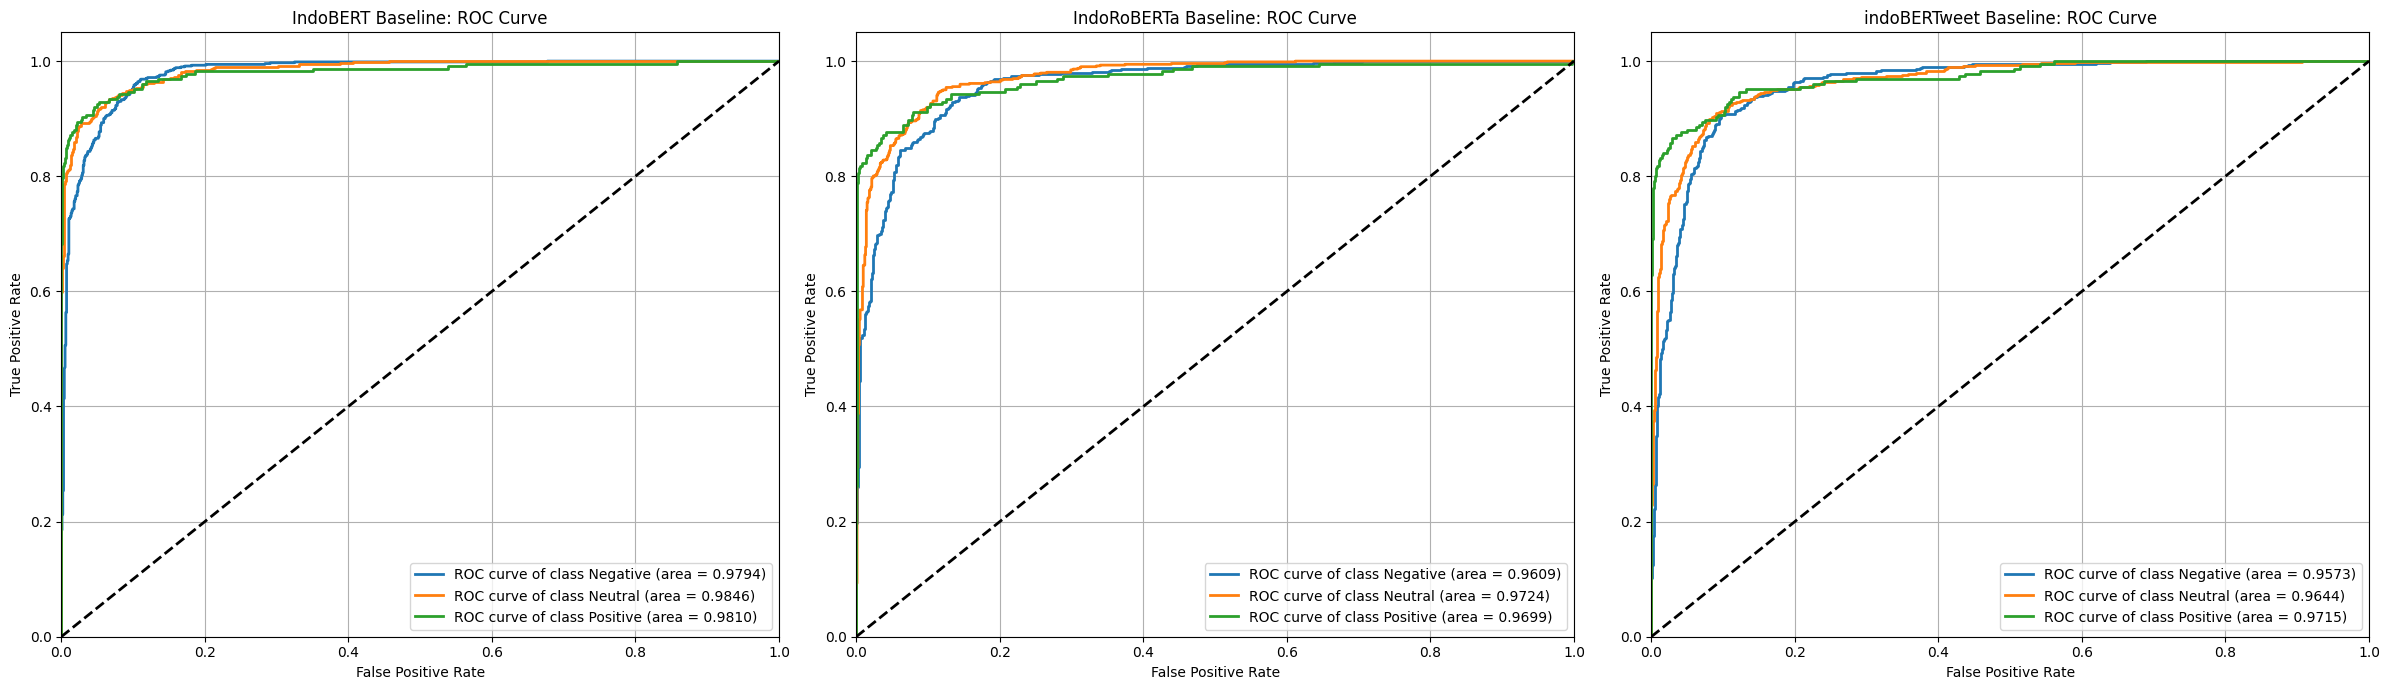

In [41]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_auc_multiclass(y_true, y_prob, labels, title="ROC Curve (One-vs-Rest)", ax=None):
    """Plots multi-class ROC AUC curves (One-vs-Rest strategy)."""
    # Binarize the true labels to a one-hot format
    lb = LabelBinarizer()
    y_true_binarized = lb.fit_transform(y_true)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    n_classes = len(labels)

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve of class {labels[i]} (area = {roc_auc[i]:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal line
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True)

# --- Plotting ROC AUC for all models ---
plt.figure(figsize=(24, 7))

# IndoBERT ROC AUC
ax1 = plt.subplot(1, 3, 1)
plot_roc_auc_multiclass(
    y_true=np.array(final_val_labels_indobert),
    y_prob=np.array(final_val_probs_indobert),
    labels=unique_labels,
    title='IndoBERT Baseline: ROC Curve',
    ax=ax1
)

# IndoRoBERTa ROC AUC
ax2 = plt.subplot(1, 3, 2)
plot_roc_auc_multiclass(
    y_true=np.array(final_val_labels_indoroberta),
    y_prob=np.array(final_val_probs_indoroberta),
    labels=unique_labels,
    title='IndoRoBERTa Baseline: ROC Curve',
    ax=ax2
)

# indoBERTweet ROC AUC
ax3 = plt.subplot(1, 3, 3)
plot_roc_auc_multiclass(
    y_true=np.array(final_val_labels_indobertweet),
    y_prob=np.array(final_val_probs_indobertweet),
    labels=unique_labels,
    title='indoBERTweet Baseline: ROC Curve',
    ax=ax3
)

plt.tight_layout()
plt.show()

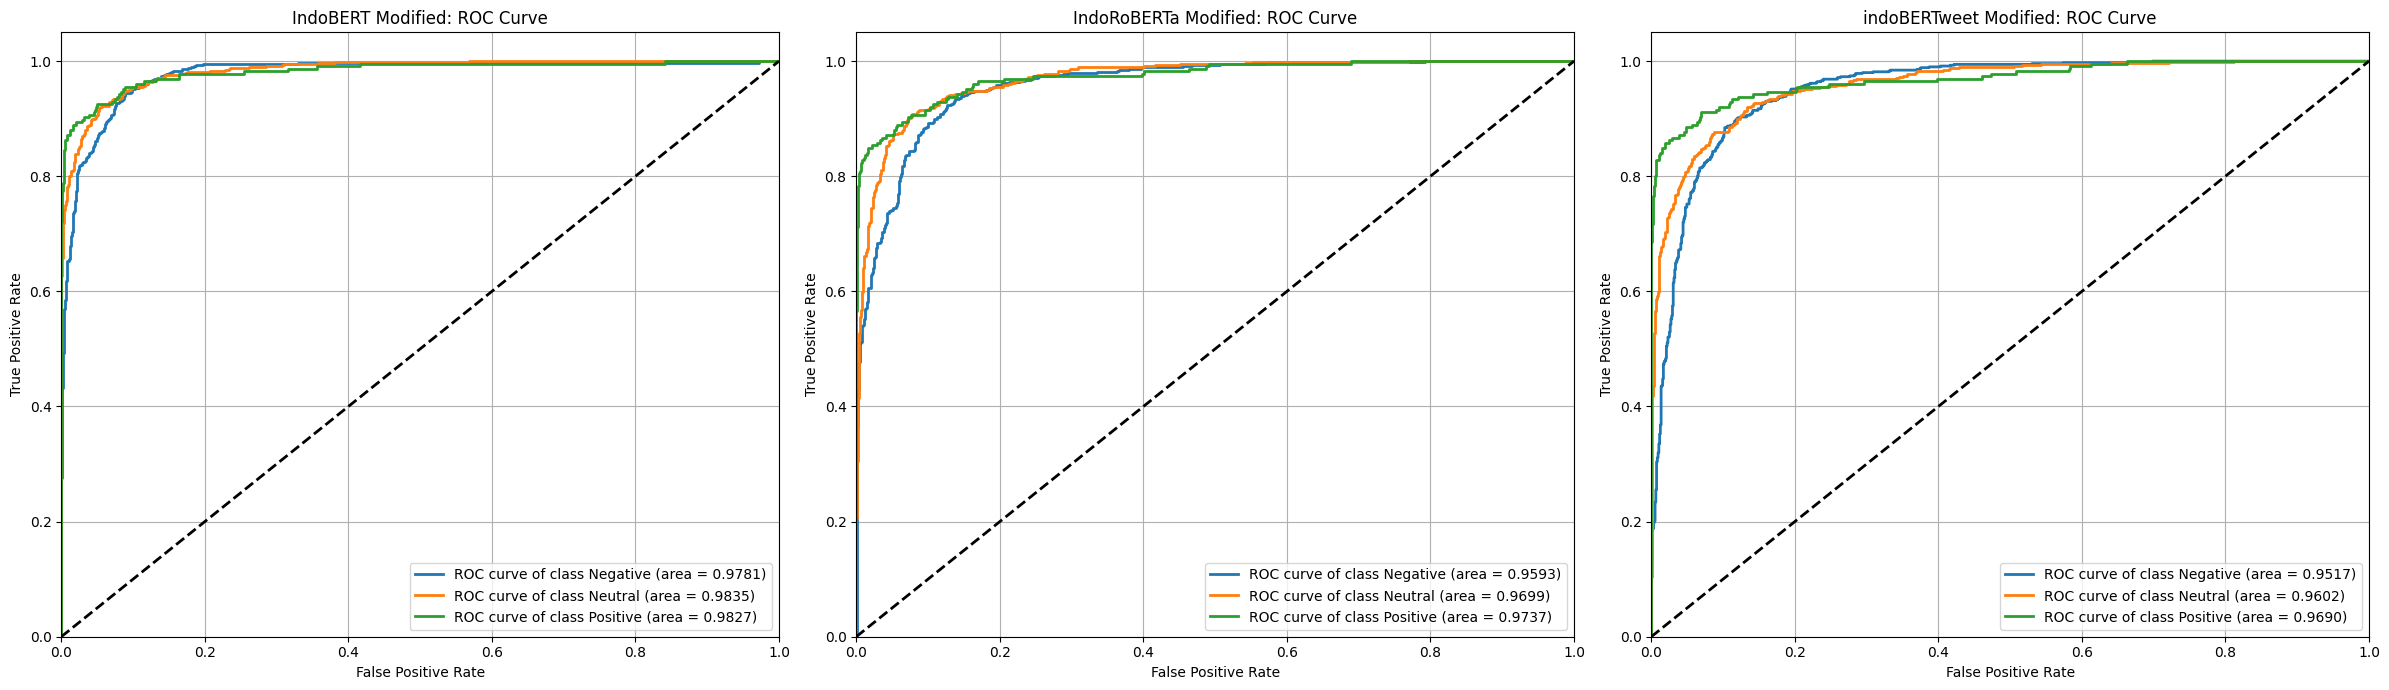

In [42]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_auc_multiclass(y_true, y_prob, labels, title="ROC Curve (One-vs-Rest)", ax=None):
    """Plots multi-class ROC AUC curves (One-vs-Rest strategy)."""
    # Binarize the true labels to a one-hot format
    lb = LabelBinarizer()
    y_true_binarized = lb.fit_transform(y_true)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    n_classes = len(labels)

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve of class {labels[i]} (area = {roc_auc[i]:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal line
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True)

# --- Plotting ROC AUC for all models ---
plt.figure(figsize=(24, 7))

# IndoBERT ROC AUC
ax1 = plt.subplot(1, 3, 1)
plot_roc_auc_multiclass(
    y_true=np.array(final_val_labels_indobert_modified),
    y_prob=np.array(final_val_probs_indobert_modified),
    labels=unique_labels,
    title='IndoBERT Modified: ROC Curve',
    ax=ax1
)

# IndoRoBERTa ROC AUC
ax2 = plt.subplot(1, 3, 2)
plot_roc_auc_multiclass(
    y_true=np.array(final_val_labels_indoroberta_modified),
    y_prob=np.array(final_val_probs_indoroberta_modified),
    labels=unique_labels,
    title='IndoRoBERTa Modified: ROC Curve',
    ax=ax2
)

# indoBERTweet ROC AUC
ax3 = plt.subplot(1, 3, 3)
plot_roc_auc_multiclass(
    y_true=np.array(final_val_labels_indobertweet_modified),
    y_prob=np.array(final_val_probs_indobertweet_modified),
    labels=unique_labels,
    title='indoBERTweet Modified: ROC Curve',
    ax=ax3
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5889/1395753330.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=df_accuracy_sorted, palette="viridis")
/tmp/ipykernel_5889/1395753330.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="F1 Score", y="Model", data=df_f1_sorted, palette="magma")


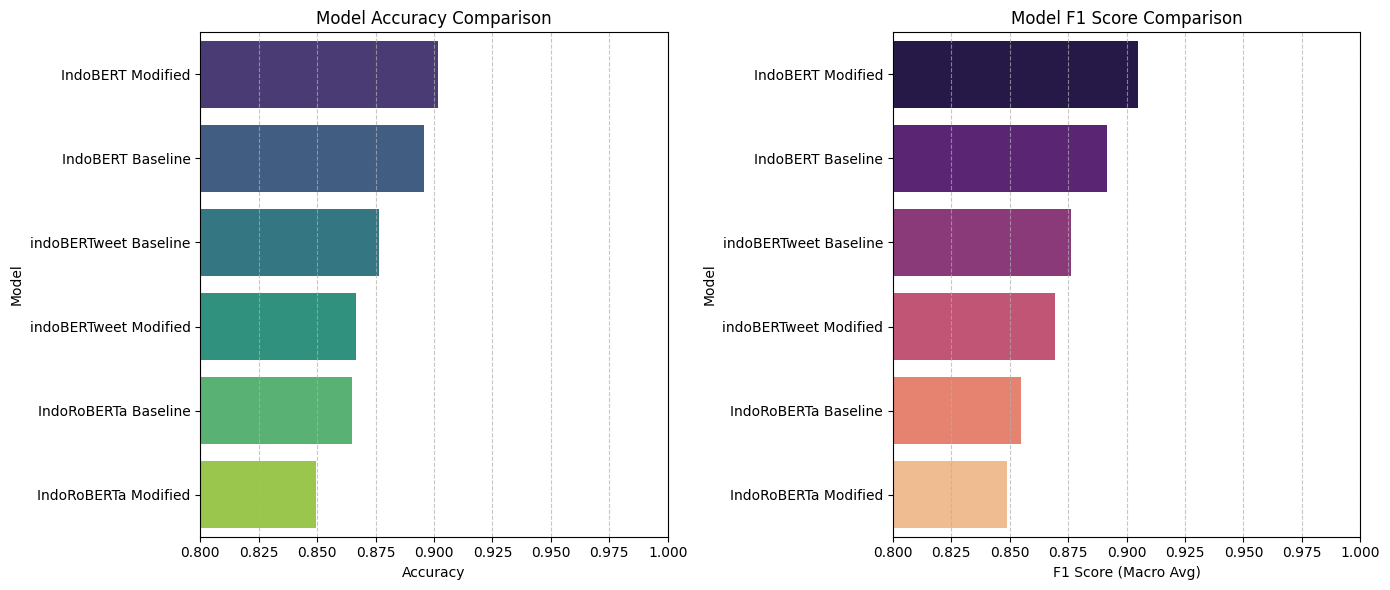

In [43]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics for each model dynamically
acc_indobert_baseline = accuracy_score(y_true_indobert, y_pred_indobert)
f1_indobert_baseline = f1_score(y_true_indobert, y_pred_indobert, average='macro')

acc_indobert_modified = accuracy_score(y_true_indobert_modified, y_pred_indobert_modified)
f1_indobert_modified = f1_score(y_true_indobert_modified, y_pred_indobert_modified, average='macro')

acc_indoroberta_baseline = accuracy_score(y_true_roberta, y_pred_roberta)
f1_indoroberta_baseline = f1_score(y_true_roberta, y_pred_roberta, average='macro')

acc_indoroberta_modified = accuracy_score(y_true_roberta_modified, y_pred_roberta_modified)
f1_indoroberta_modified = f1_score(y_true_roberta_modified, y_pred_roberta_modified, average='macro')

acc_indobertweet_baseline = accuracy_score(y_true_indobertweet, y_pred_indobertweet)
f1_indobertweet_baseline = f1_score(y_true_indobertweet, y_pred_indobertweet, average='macro')

# Recalculate metrics for indoBERTweet Modified (assuming y_true_electra_modified and y_pred_electra_modified are for this model)
acc_indobertweet_modified = accuracy_score(y_true_electra_modified, y_pred_electra_modified)
f1_indobertweet_modified = f1_score(y_true_electra_modified, y_pred_electra_modified, average='macro')

# Collect all metrics
results = [
    {"Model": "IndoBERT Baseline", "Accuracy": acc_indobert_baseline, "F1 Score": f1_indobert_baseline},
    {"Model": "IndoBERT Modified", "Accuracy": acc_indobert_modified, "F1 Score": f1_indobert_modified},
    {"Model": "IndoRoBERTa Baseline", "Accuracy": acc_indoroberta_baseline, "F1 Score": f1_indoroberta_baseline},
    {"Model": "IndoRoBERTa Modified", "Accuracy": acc_indoroberta_modified, "F1 Score": f1_indoroberta_modified},
    {"Model": "indoBERTweet Baseline", "Accuracy": acc_indobertweet_baseline, "F1 Score": f1_indobertweet_baseline},
    {"Model": "indoBERTweet Modified", "Accuracy": acc_indobertweet_modified, "F1 Score": f1_indobertweet_modified}
]

df_results = pd.DataFrame(results)

# Sort by Accuracy
df_accuracy_sorted = df_results.sort_values(by="Accuracy", ascending=False)

# Sort by F1 Score
df_f1_sorted = df_results.sort_values(by="F1 Score", ascending=False)

# Create the plots
plt.figure(figsize=(14, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x="Accuracy", y="Model", data=df_accuracy_sorted, palette="viridis")
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0.8, 1.0) # Set x-axis limit for better visualization
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot F1 Score
plt.subplot(1, 2, 2)
sns.barplot(x="F1 Score", y="Model", data=df_f1_sorted, palette="magma")
plt.title("Model F1 Score Comparison")
plt.xlabel("F1 Score (Macro Avg)")
plt.ylabel("Model")
plt.xlim(0.8, 1.0) # Set x-axis limit for better visualization
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()